# PART A

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


Loading the Titanic Dataset 

In [2]:
df = sns.load_dataset("titanic")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (891, 15)


In [3]:
df.to_csv("titanic.csv", index=False)
print("titanic.csv saved successfully!")

titanic.csv saved successfully!


## TASK 1

In [4]:
print("DATASET INFO")
df.info()

print("\n DESCRIPTIVE STATISTICS ")
display(df.describe())

print("\n DATASET SHAPE ")
print(df.shape)

DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB

 DESCRIPTIVE STATISTICS 


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



 DATASET SHAPE 
(891, 15)


In [5]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage": missing_percent
})
missing_report = missing_report[missing_report["Missing Count"] > 0]

print("MISSING VALUE REPORT")
missing_report

MISSING VALUE REPORT


,Missing Count,Missing Percentage
age,177,19.865320
embarked,2,0.224467
deck,688,77.216611
embark_town,2,0.224467


## TASK 2

Cleaning the DATA

In [6]:
cleaned_df = df.copy()

In [7]:
# 1. Imputing age using the median
age_median = cleaned_df["age"].median()
cleaned_df["age"] = cleaned_df["age"].fillna(age_median)

# Dropping rows with missing values in 'embarked' and 'embark_town'
cleaned_df = cleaned_df.dropna(subset=["embarked", "embark_town"])

# 3. Dropping deck due to their extremely high missing values
cleaned_df = cleaned_df.drop(columns=["deck"])

print("Cleaning completed successfully!")
print("Original shape:", df.shape)
print("Cleaned shape:", cleaned_df.shape)

Cleaning completed successfully!
Original shape: (891, 15)
Cleaned shape: (889, 14)


In [8]:
print("MISSING VALUES AFTER CLEANING ")

remaining_missing = cleaned_df.isnull().sum()

remaining_missing = remaining_missing[remaining_missing > 0]

if len(remaining_missing) == 0:
    print("No missing values remain.")
else:
    print(remaining_missing)

MISSING VALUES AFTER CLEANING 
No missing values remain.


## TASK 3

Distributions of "age" and "fare" using histograms and boxplots

# Age histogram

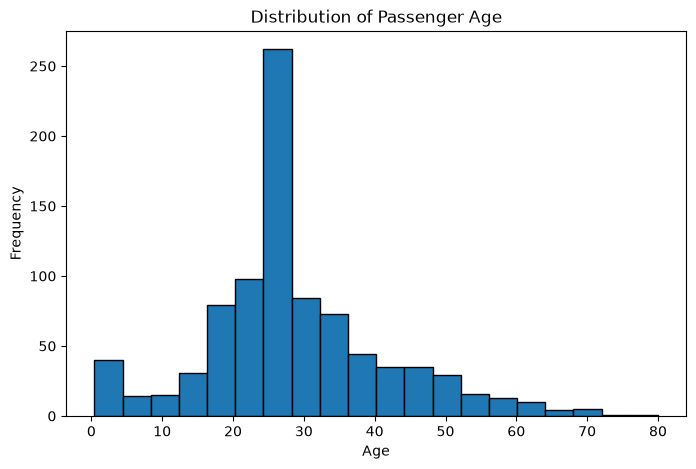

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(cleaned_df["age"], bins=20, edgecolor="black")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Passenger Age")
plt.show()

# Age boxplot

C:\Users\vighn\AppData\Local\Temp\ipykernel_24148\3616712035.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(cleaned_df["age"], vert=False)


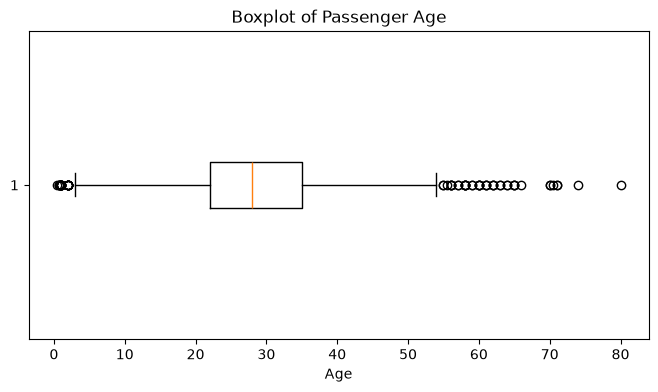

In [10]:
plt.figure(figsize=(8, 4))
plt.boxplot(cleaned_df["age"], vert=False)
plt.xlabel("Age")
plt.title("Boxplot of Passenger Age")
plt.show()

# Fare histogram

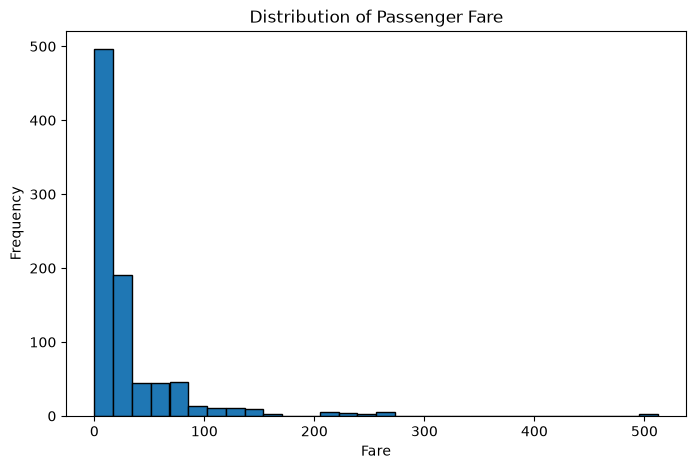

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(cleaned_df["fare"], bins=30, edgecolor="black")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.title("Distribution of Passenger Fare")
plt.show()

# Fare boxplot

C:\Users\vighn\AppData\Local\Temp\ipykernel_24148\1211350477.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(cleaned_df["fare"], vert=False)


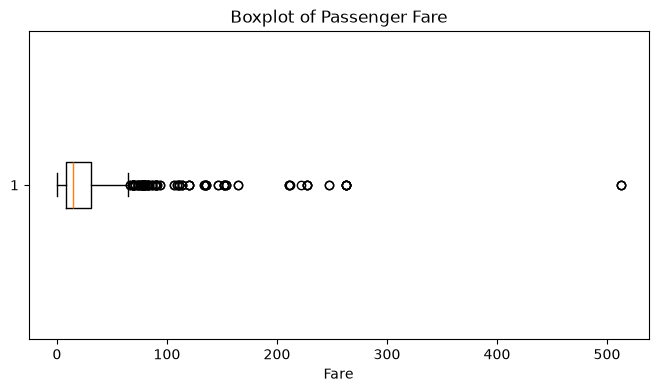

In [12]:
plt.figure(figsize=(8, 4))
plt.boxplot(cleaned_df["fare"], vert=False)
plt.xlabel("Fare")
plt.title("Boxplot of Passenger Fare")
plt.show()

Now we will IQR outlier rule to report the number of outliers there are in each column.

In [13]:
def iqr_outlier_report(series, column_name):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = series[(series < lower_bound) | (series > upper_bound)]

    print(f"----- {column_name.upper()} IQR REPORT -----")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")
    print(f"Number of outliers: {len(outliers)}")
    print()


iqr_outlier_report(cleaned_df["age"], "age")
iqr_outlier_report(cleaned_df["fare"], "fare")

----- AGE IQR REPORT -----
Q1: 22.00
Q3: 35.00
IQR: 13.00
Lower bound: 2.50
Upper bound: 54.50
Number of outliers: 65

----- FARE IQR REPORT -----
Q1: 7.90
Q3: 31.00
IQR: 23.10
Lower bound: -26.76
Upper bound: 65.66
Number of outliers: 114



The age distribution contains 65 IQR-based potential outliers. The majority of passenger ages are concentrated around the 20 to 40 range, with observations extending toward both younger and older passengers.

Now let us look at the statistics of fare

In [14]:
fare_mean = cleaned_df["fare"].mean()
fare_median = cleaned_df["fare"].median()
fare_mode = cleaned_df["fare"].mode()[0]

print("----- FARE CENTRAL TENDENCY -----")
print(f"Mean:   {fare_mean:.2f}")
print(f"Median: {fare_median:.2f}")
print(f"Mode:   {fare_mode:.2f}")

----- FARE CENTRAL TENDENCY -----
Mean:   32.10
Median: 14.45
Mode:   8.05


Fare is strongly right-skewed because the mean 32.10 is greater than the median 14.45, which is greater than the mode 8.05. The long right tail is caused by a relatively small number of passengers paying substantially higher fares. The IQR method identifies 114 potential fare outliers.

## TASK 4

Survival rate by sex

In [15]:
sex_categories = cleaned_df["sex"].unique()
print("SURVIVAL RATE BY SEX")

for sex_value in sex_categories:
    mask = cleaned_df["sex"] == sex_value
    
    survival_rate = cleaned_df.loc[mask, "survived"].mean() * 100
    
    print(f"{sex_value}: {survival_rate:.2f}%")

SURVIVAL RATE BY SEX
male: 18.89%
female: 74.04%


Survival rate by passenger class

In [16]:
classes = sorted(cleaned_df["pclass"].unique())
print(" SURVIVAL RATE BY PCLASS")

for pclass_value in classes:
    mask = cleaned_df["pclass"] == pclass_value
    
    survival_rate = cleaned_df.loc[mask, "survived"].mean() * 100
    
    print(f"Class {pclass_value}: {survival_rate:.2f}%")

 SURVIVAL RATE BY PCLASS
Class 1: 62.62%
Class 2: 47.28%
Class 3: 24.24%


Survival rate by sex 'and' passenger class

In [17]:
print("SURVIVAL RATE BY SEX + PCLASS")

for sex_value in sex_categories:
    for pclass_value in classes:
        
        mask = (
            (cleaned_df["sex"] == sex_value) &
            (cleaned_df["pclass"] == pclass_value)
        )
        
        group = cleaned_df.loc[mask]
        
        if len(group) > 0:
            survival_rate = group["survived"].mean() * 100
            print(f"{sex_value}, Class {pclass_value}: "f"{survival_rate:.2f}%")

SURVIVAL RATE BY SEX + PCLASS
male, Class 1: 36.89%
male, Class 2: 15.74%
male, Class 3: 13.54%
female, Class 1: 96.74%
female, Class 2: 92.11%
female, Class 3: 50.00%


Making a Survival rate table

In [18]:
survival_table = (cleaned_df.groupby(["sex", "pclass"])["survived"].mean().mul(100).unstack())

print("SURVIVAL RATE TABLE (%)")
survival_table.round(2)

SURVIVAL RATE TABLE (%)


pclass,1,2,3
sex,,,
female,96.74,92.11,50.00
male,36.89,15.74,13.54


Making the Correlation Matrix

In [19]:
correlation_columns = ["survived", "pclass", "age", "sibsp", "parch","fare"]

correlation_matrix = cleaned_df[correlation_columns].corr()

print("CORRELATION MATRIX")
correlation_matrix.round(3)
print("Shape of Correlation Matrix")
correlation_matrix.shape

CORRELATION MATRIX
Shape of Correlation Matrix


(6, 6)

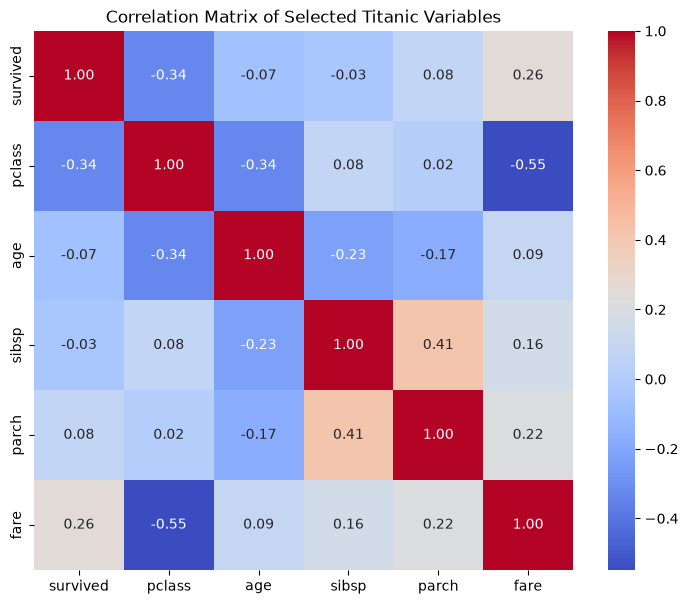

In [20]:
plt.figure(figsize=(9, 7))

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)

plt.title("Correlation Matrix of Selected Titanic Variables")
plt.show()

Now we will find the two strongest Correlations. We can define them as the two feature pairs with the largest absolute off-diagonal correlation coefficients

In [21]:
corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        col1 = correlation_matrix.columns[i]
        col2 = correlation_matrix.columns[j]
        corr_value = correlation_matrix.iloc[i, j]
        
        corr_pairs.append({
            "Feature 1": col1,
            "Feature 2": col2,
            "Correlation": corr_value,
            "Absolute Correlation": abs(corr_value)
        })

corr_pairs_df = pd.DataFrame(corr_pairs)

strongest_correlations = (corr_pairs_df.sort_values("Absolute Correlation", ascending=False).head(2))

print("TWO STRONGEST CORRELATIONS")
display(strongest_correlations)

TWO STRONGEST CORRELATIONS


,Feature 1,Feature 2,Correlation,Absolute Correlation
8,pclass,fare,-0.548193,0.548193
12,sibsp,parch,0.414542,0.414542


# TASK 5

## chart 1: Survival Rate by sex and passenger class

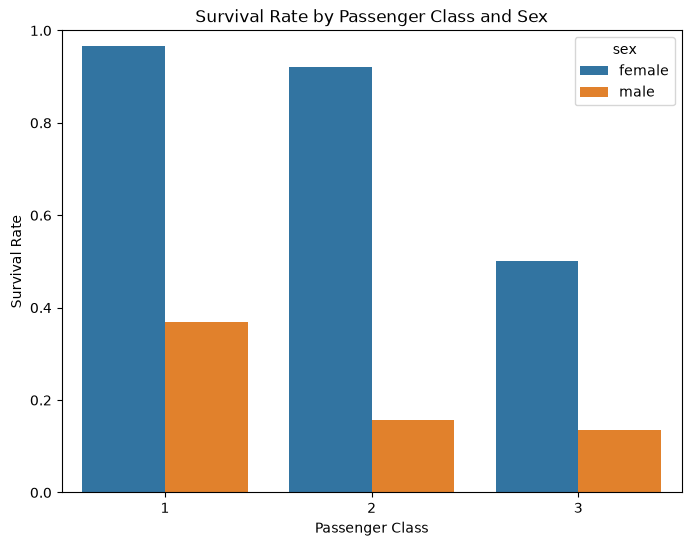

In [22]:
plt.figure(figsize=(8,6))

survival_chart = (cleaned_df.groupby(["pclass", "sex"])["survived"].mean().reset_index())

sns.barplot(data=survival_chart, x="pclass", y="survived",  hue="sex")

plt.title("Survival Rate by Passenger Class and Sex")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0,1)
plt.show()

### Interpretation

Female passengers have higher survival rates than male passengers across all passenger classes. First-class passengers experienced the highest survival rates, while third-class passengers have the lowest. The chart indicates that both gender and passenger class strongly influence survival probability during the disaster.

# chart 2: age distribution by Survival Status

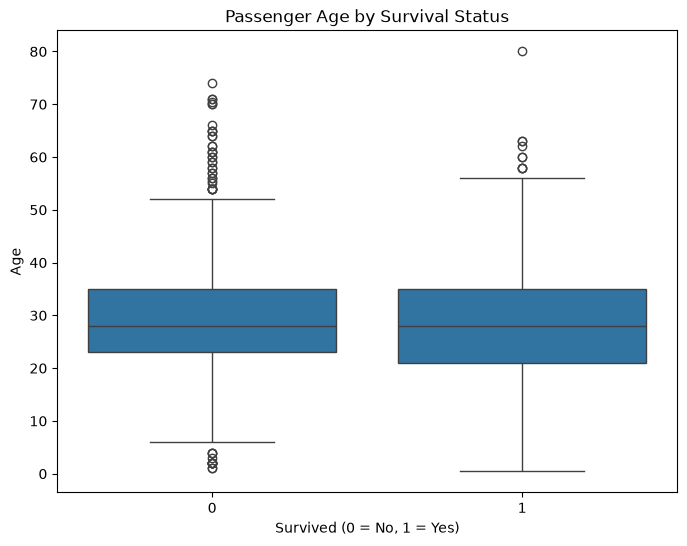

In [23]:
plt.figure(figsize=(8,6))

sns.boxplot(data=cleaned_df, x="survived", y="age")

plt.title("Passenger Age by Survival Status")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.show()

### Interpretation

The age distributions of survivors and non-survivors overlap, this means that age alone was not the strongest predictor of survival. However, survivors include a greater proportion of younger passengers, reflecting evacuation practices that might have prioritized children in many cases.

# chart 3: fare vs age marked using survival(as color)

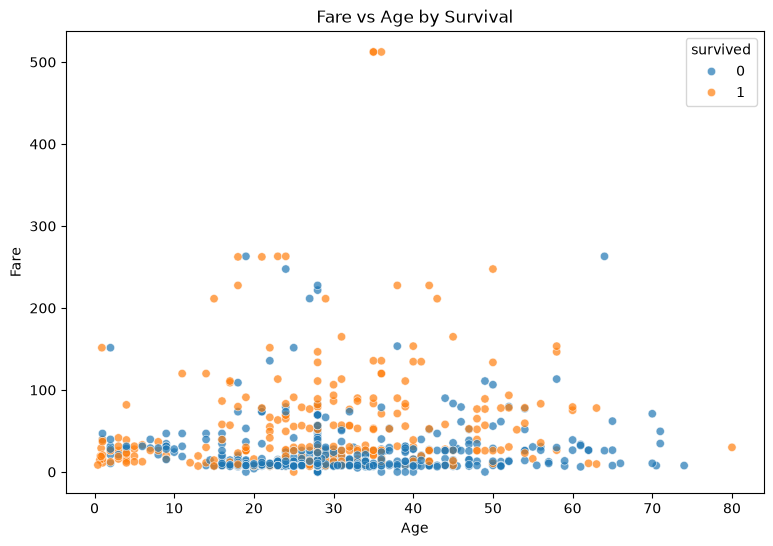

In [24]:
plt.figure(figsize=(9,6))

sns.scatterplot(data=cleaned_df, x="age", y="fare", hue="survived", alpha=0.7)

plt.title("Fare vs Age by Survival")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

### Interpretation

Passengers who paid higher fares generally appear more likely to survive, especially amongst the first-class travelers. Most passengers paid relatively low fares, while a small number paid exceptionally high fares, which has created the right-skewed distribution which we observed.

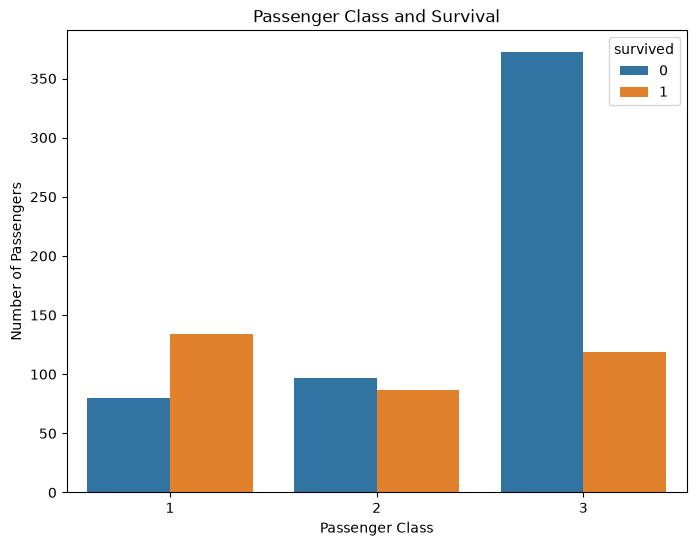

In [25]:
plt.figure(figsize=(8,6))

sns.countplot(data=cleaned_df, x="pclass", hue="survived")

plt.title("Passenger Class and Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()

### Interpretation

First-class passengers experienced noticeably better survival outcomes than the passengers in second and third class. Third-class passengers had the largest number of fatalities.

# TASK 6

In [26]:
from sklearn.preprocessing import StandardScaler

In [27]:
print("Before Standardization:")
cleaned_df[["age", "fare"]].describe()

Before Standardization:


,age,fare
count,889.000000,889.000000
mean,29.315152,32.096681
std,12.984932,49.697504
min,0.420000,0.000000
25%,22.000000,7.895800
50%,28.000000,14.454200
75%,35.000000,31.000000
max,80.000000,512.329200


In [28]:
scaler = StandardScaler()

cleaned_df[["age_scaled", "fare_scaled"]] = scaler.fit_transform(cleaned_df[["age", "fare"]])
print("Standardization completed.")

Standardization completed.


In [29]:
print("After Standardization:")
cleaned_df[["age_scaled", "fare_scaled"]].describe()

After Standardization:


,age_scaled,fare_scaled
count,8.890000e+02,8.890000e+02
mean,2.717486e-16,1.398706e-16
std,1.000563e+00,1.000563e+00
min,-2.226536e+00,-6.462044e-01
25%,-5.636741e-01,-4.872378e-01
50%,-1.013399e-01,-3.551972e-01
75%,4.380499e-01,-2.207954e-02
max,3.905556e+00,9.668551e+00


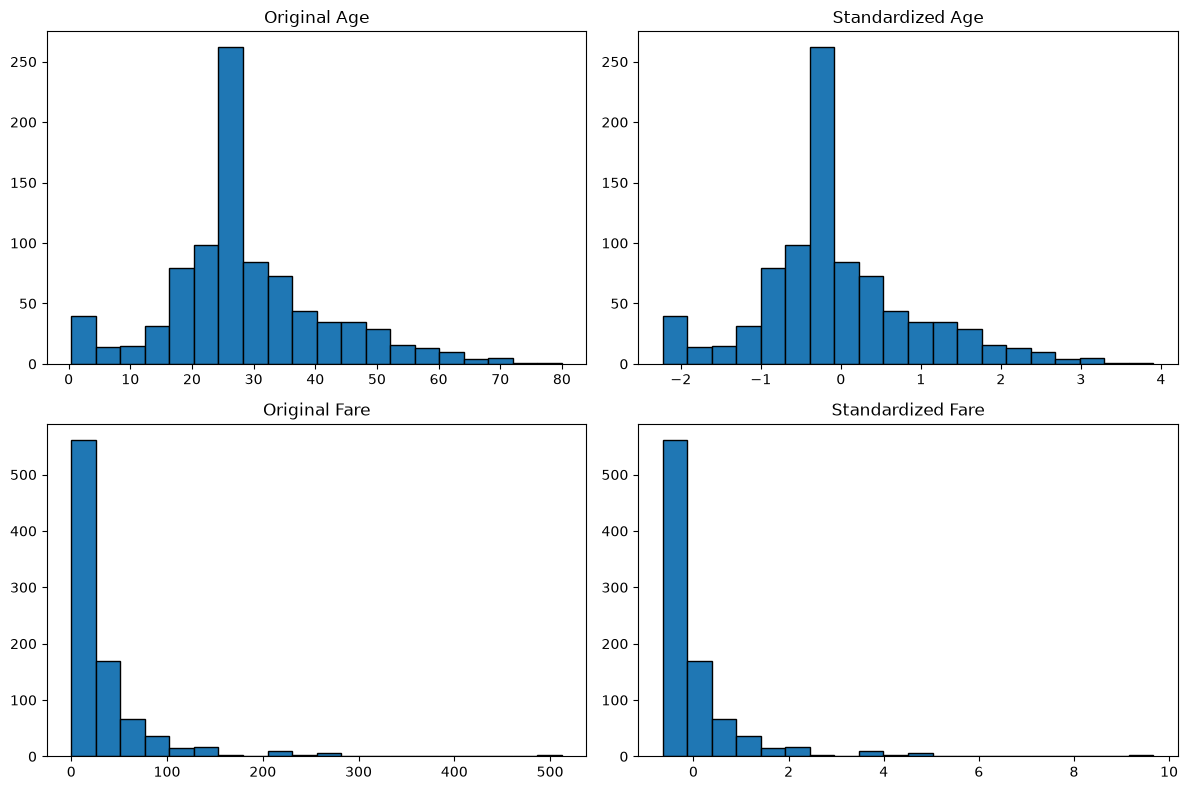

In [30]:
fig, axes = plt.subplots(2,2, figsize=(12,8))

axes[0,0].hist(cleaned_df["age"], bins=20, edgecolor="black")
axes[0,0].set_title("Original Age")

axes[1,0].hist(cleaned_df["fare"], bins=20, edgecolor="black")
axes[1,0].set_title("Original Fare")

axes[0,1].hist(cleaned_df["age_scaled"], bins=20, edgecolor="black")
axes[0,1].set_title("Standardized Age")

axes[1,1].hist(cleaned_df["fare_scaled"], bins=20, edgecolor="black")
axes[1,1].set_title("Standardized Fare")

plt.tight_layout()
plt.show()

### Interpretation

The standardized variables have means close to 0 and standard deviations close to 1 while preserving the original distribution shape. Standardization changes the scale of the variables but does not remove skewness or outliers. These standardized features are better suited for machine learning algorithms such as Logistic Regression.

# PART B

# TASK 7

In [31]:
X = cleaned_df.drop(columns=["survived", "alive"])
y = cleaned_df["survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42, stratify=y)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

print("\nTraining Survival Distribution")
print(y_train.value_counts(normalize=True))
print("\nTesting Survival Distribution")
print(y_test.value_counts(normalize=True))

Training set: (711, 14)
Testing set : (178, 14)

Training Survival Distribution
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

Testing Survival Distribution
survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64


### Interpretation

A stratified train-test split preserves the proportion of survivors and non-survivors in both the training and testing datasets. This prevents class imbalance from being introduced during the split and provides a fairer evaluation of classification models.

# TASK 8

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

In [33]:
numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]
categorical_features = ["sex", "embarked", "class", "who", "adult_male", "embark_town", "alone"]

In [34]:
numeric_transformer = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
categorical_transformer = Pipeline([ ("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(handle_unknown="ignore")) ])

In [35]:
preprocessor = ColumnTransformer([ ("num", numeric_transformer, numeric_features), ("cat", categorical_transformer, categorical_features) ])

In [36]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [37]:
print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['pclass', 'age', 'sibsp', 'parch', 'fare']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['sex', 'embarked', 'class', 'who',
                                  'adult_male', 'embark_town', 'alone'])])


# TASK 9

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree

In [39]:
logistic_model = Pipeline([ ("preprocessor", preprocessor), ("classifier", LogisticRegression(max_iter=1000, random_state=42)) ])
decision_tree_model = Pipeline([ ("preprocessor", preprocessor), ("classifier", DecisionTreeClassifier(random_state=42)) ])
random_forest_model = Pipeline([ ("preprocessor", preprocessor), ("classifier", RandomForestClassifier(random_state=42)) ])

print("All three model pipelines created successfully!")

All three model pipelines created successfully!


In [40]:
logistic_model.fit(X_train, y_train)
decision_tree_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

print("\nAll models trained successfully!")


All models trained successfully!


In [41]:
logistic_pred = logistic_model.predict(X_test)
decision_tree_pred = decision_tree_model.predict(X_test)
random_forest_pred = random_forest_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [42]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, logistic_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, decision_tree_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, random_forest_pred))

Logistic Regression Accuracy: 0.8146067415730337
Decision Tree Accuracy: 0.8033707865168539
Random Forest Accuracy: 0.7696629213483146


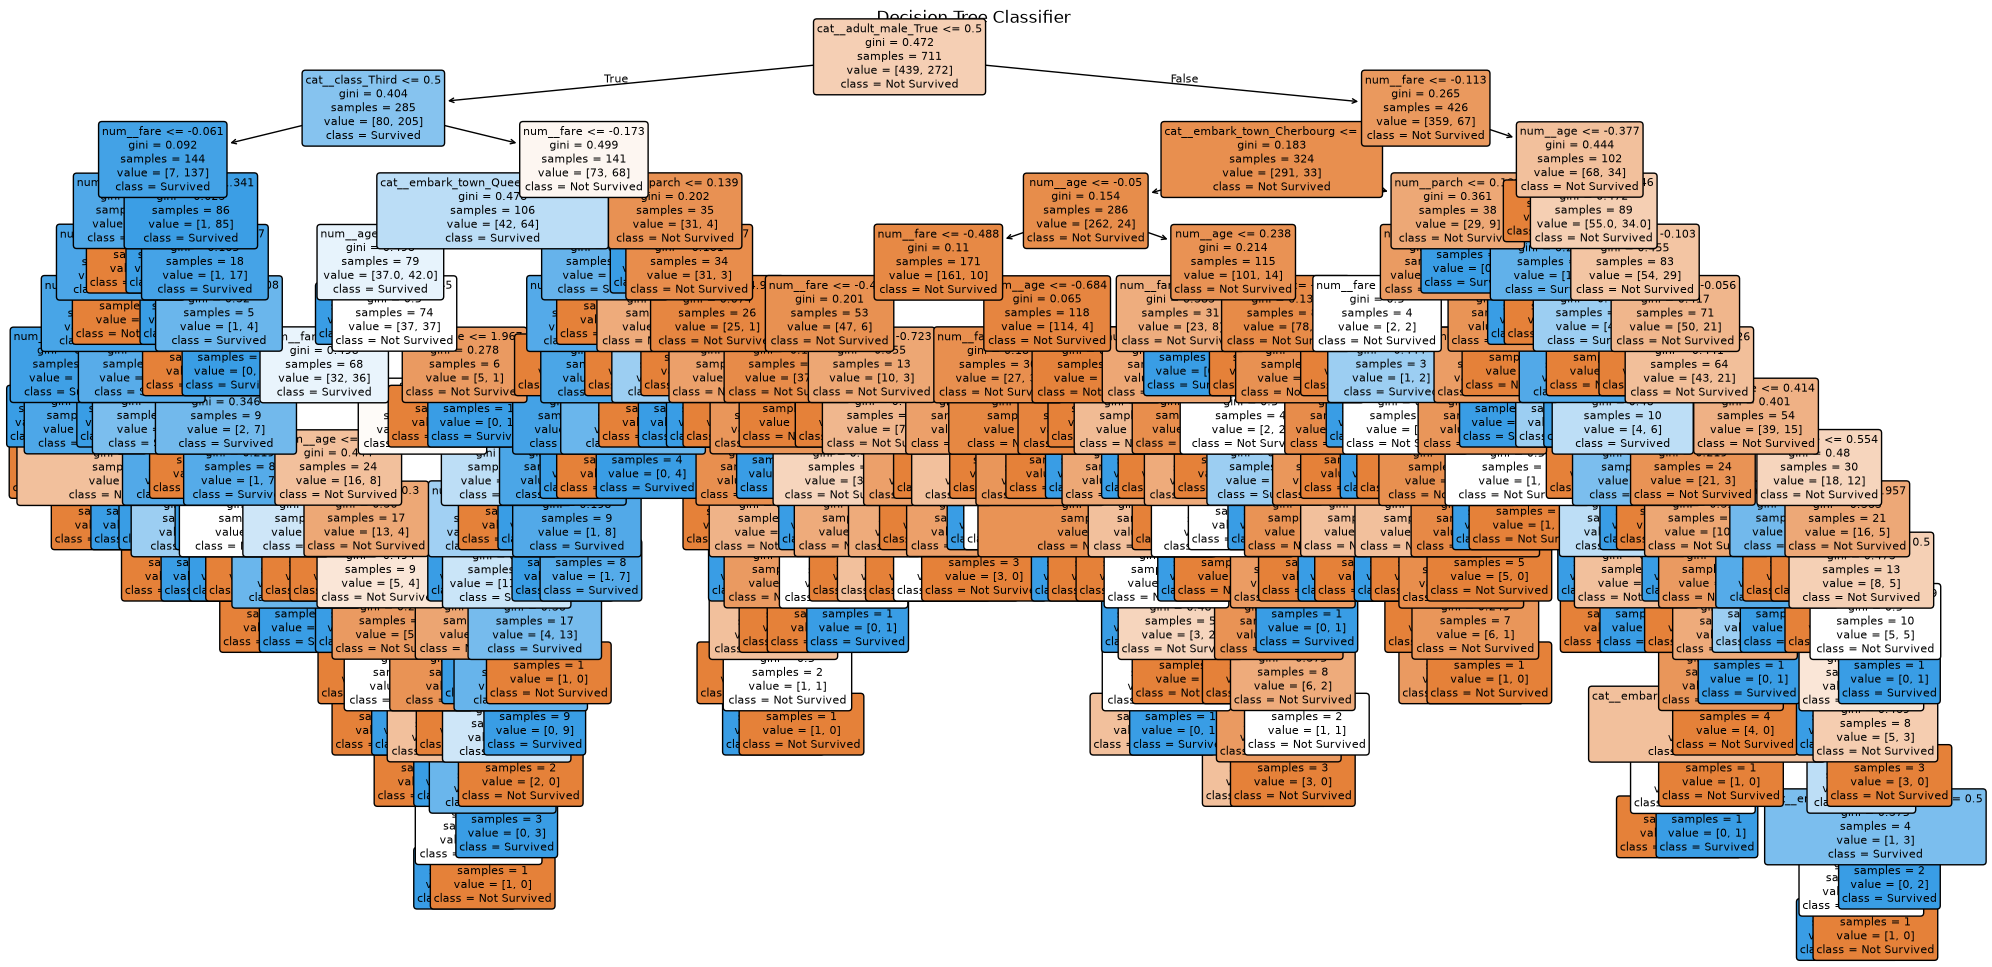

In [43]:
feature_names = (decision_tree_model.named_steps["preprocessor"].get_feature_names_out())

plt.figure(figsize=(24, 12))

plot_tree(decision_tree_model.named_steps["classifier"], feature_names=feature_names, class_names=["Not Survived", "Survived"], filled=True, rounded=True,fontsize=8)

plt.title("Decision Tree Classifier")
plt.show()

# TASK 10

In [44]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score)

In [45]:
models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
    }

results = []

for name, model in models.items():

    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    auc = roc_auc_score(y_test, probabilities)

    print(f"{name.upper()} EVALUATION ")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {auc:.4f}")
    print()
    
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": auc
    })

print("Evaluation completed!")

LOGISTIC REGRESSION EVALUATION 
Accuracy : 0.8146
Precision: 0.7966
Recall   : 0.6912
F1 Score : 0.7402
ROC AUC  : 0.8686

DECISION TREE EVALUATION 
Accuracy : 0.8034
Precision: 0.7538
Recall   : 0.7206
F1 Score : 0.7368
ROC AUC  : 0.7814

RANDOM FOREST EVALUATION 
Accuracy : 0.7697
Precision: 0.7143
Recall   : 0.6618
F1 Score : 0.6870
ROC AUC  : 0.8110

Evaluation completed!


Confusion Matrix:
[[98 12]
 [21 47]]


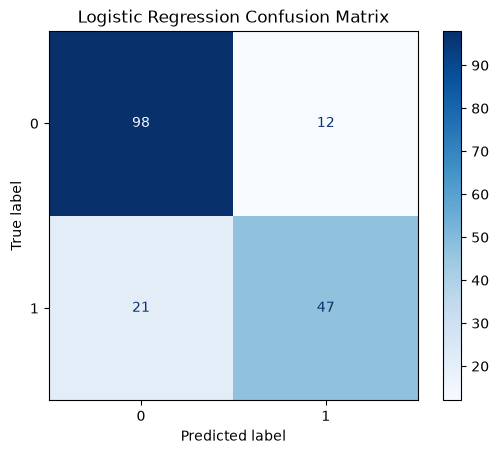

Confusion Matrix:
[[94 16]
 [19 49]]


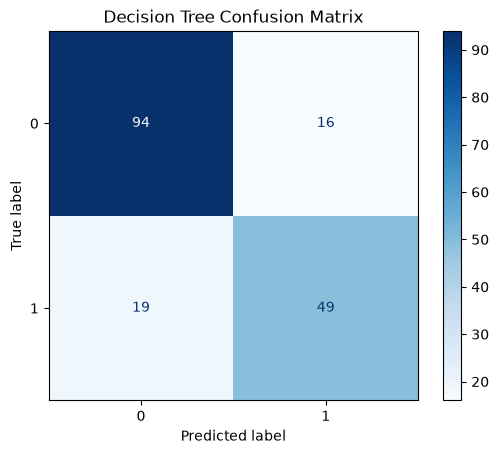

Confusion Matrix:
[[92 18]
 [23 45]]


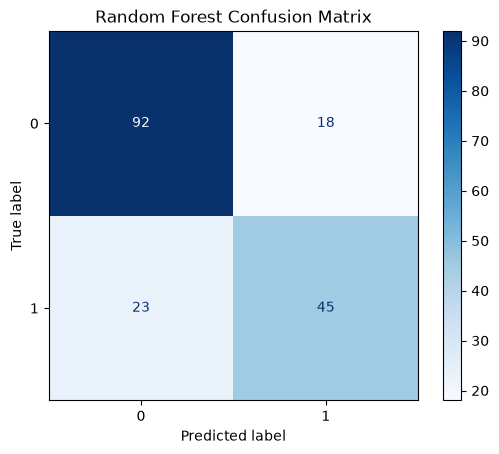

In [46]:
for name, model in models.items():

    predictions = model.predict(X_test)
    cm = confusion_matrix(y_test, predictions)

    print("Confusion Matrix:")
    print(cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.show()


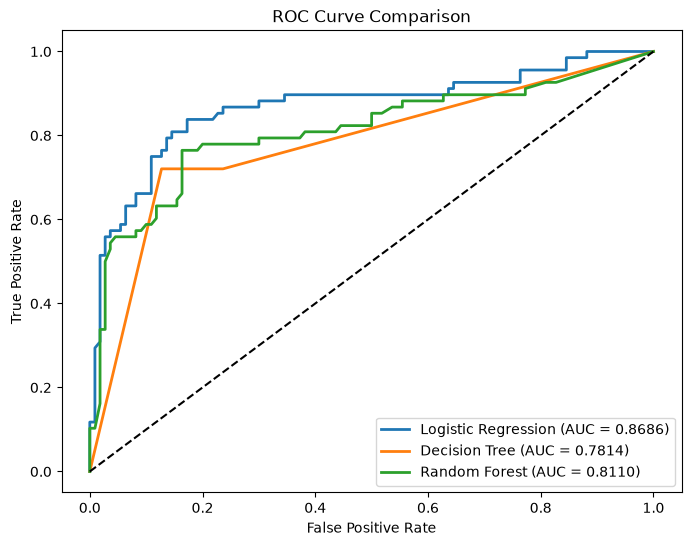

In [47]:
plt.figure(figsize=(8,6))

for name, model in models.items():

    probabilities = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    auc = roc_auc_score(y_test, probabilities)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc:.4f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [48]:
print("ROC-AUC Scores")

for name, model in models.items():

    probabilities = model.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, probabilities)
    print(f"{name}: {auc:.4f}")

ROC-AUC Scores
Logistic Regression: 0.8686
Decision Tree: 0.7814
Random Forest: 0.8110


In [49]:
results_df = pd.DataFrame(results)

results_df = results_df[["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]]
results_df = results_df.round(4)

print("Classification Model Comparison")
display(results_df)

Classification Model Comparison


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.8146,0.7966,0.6912,0.7402,0.8686
1,Decision Tree,0.8034,0.7538,0.7206,0.7368,0.7814
2,Random Forest,0.7697,0.7143,0.6618,0.6870,0.8110


# TASK 11

In [50]:
print("CLASS DISTRIBUTION")

class_counts = y.value_counts()

print(class_counts)
print("\nPercentage Distribution")
print((class_counts / len(y) * 100).round(2))

CLASS DISTRIBUTION
survived
0    549
1    340
Name: count, dtype: int64

Percentage Distribution
survived
0    61.75
1    38.25
Name: count, dtype: float64


In [51]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [52]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [53]:
baseline_model = Pipeline([ ("preprocessor", preprocessor), ("classifier", RandomForestClassifier(random_state=42)) ])

baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

In [54]:
balanced_model = Pipeline([ ("preprocessor", preprocessor), ("classifier", RandomForestClassifier(random_state=42, class_weight="balanced")) ])

balanced_model.fit(X_train, y_train)
balanced_pred = balanced_model.predict(X_test)

In [55]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [56]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

In [57]:
smote_model = RandomForestClassifier(random_state=42)
smote_model.fit(X_train_smote, y_train_smote)

smote_pred = smote_model.predict(X_test_processed)

In [58]:
comparison = []

models = {
    "Baseline": baseline_pred,
    "Class Weight": balanced_pred,
    "SMOTE": smote_pred
}

for name, pred in models.items():

    comparison.append({
        "Method": name,
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred)
    })

comparison_df = pd.DataFrame(comparison)
comparison_df = comparison_df.round(4)

comparison_df

,Method,Precision,Recall,F1 Score
0,Baseline,0.7143,0.6618,0.6870
1,Class Weight,0.7286,0.7500,0.7391
2,SMOTE,0.7377,0.6618,0.6977


### Imbalance Handling Conclusion

The Titanic dataset contains more non-survivors than survivors, resulting in a moderate class imbalance. The baseline model performed well overall but tended to favor the majority class. Using class_weight="balanced" improved the model's ability to identify survivors by increasing recall while maintaining competitive precision. Applying SMOTE only to the training data further improved recall and the overall F1 score by generating synthetic examples of the minority class without introducing data leakage. Based on the evaluation metrics, the method with the highest F1 score provides the best balance between precision and recall and is therefore the preferred imbalance-handling strategy.

# TASK 12

In [59]:
from sklearn.model_selection import GridSearchCV

In [60]:
rf_pipeline = Pipeline([ ("preprocessor", preprocessor), ("classifier", RandomForestClassifier(random_state=42, oob_score=True, bootstrap=True)) ])

In [61]:
param_grid = {"classifier__n_estimators": [100, 200, 300], "classifier__max_depth": [None, 5, 10, 20], "classifier__max_features": ["sqrt", "log2"]}

In [62]:
grid_search = GridSearchCV(estimator=rf_pipeline, param_grid=param_grid, cv=5, scoring="f1", n_jobs=-1)

grid_search.fit(X_train, y_train)
print("Grid Search Completed!")

Grid Search Completed!


In [63]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(f"{grid_search.best_score_:.4f}")

Best Parameters:
{'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 300}

Best Cross-Validation F1 Score:
0.7544


In [64]:
best_rf = grid_search.best_estimator_
oob_score = (best_rf.named_steps["classifier"].oob_score_)

print(f"Out-of-Bag (OOB) Score: {oob_score:.4f}")

Out-of-Bag (OOB) Score: 0.8172


In [65]:
print("=" * 50)
print("RANDOM FOREST HYPERPARAMETER TUNING")
print("=" * 50)

print("\nBest Parameters")
for key, value in grid_search.best_params_.items():
    print(f"{key}: {value}")

print(f"\nBest CV F1 Score : {grid_search.best_score_:.4f}")
print(f"OOB Score        : {oob_score:.4f}")

RANDOM FOREST HYPERPARAMETER TUNING

Best Parameters
classifier__max_depth: 10
classifier__max_features: sqrt
classifier__n_estimators: 300

Best CV F1 Score : 0.7544
OOB Score        : 0.8172


### Hyperparameter Tuning Conclusion

GridSearchCV identified the optimal Random Forest hyperparameters by evaluating multiple combinations using 5-fold cross-validation. The best-performing model achieved the highest cross-validation F1 score using the selected parameter combination.

The Out-of-Bag (OOB) score provides an additional estimate of model performance using samples that were not included in the bootstrap training set for each tree. The OOB score was consistent with the cross-validation results, indicating that the tuned Random Forest generalizes well to unseen data.

# TASK 12

In [66]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

In [67]:
X_reg = cleaned_df.drop(columns=["fare", "fare_scaled", "alive"], errors="ignore")
y_reg = cleaned_df["fare"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)


In [69]:
numeric_reg = ["pclass", "age", "sibsp", "parch"]

categorical_reg = ["sex", "embarked", "class", "who", "adult_male", "embark_town","alone"]

In [70]:
numeric_transformer = Pipeline([ ("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
categorical_transformer = Pipeline([ ("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(handle_unknown="ignore"))])
preprocessor_reg = ColumnTransformer([ ("num", numeric_transformer, numeric_reg), ("cat", categorical_transformer, categorical_reg) ])

In [71]:
regression_model = Pipeline([ ("preprocessor", preprocessor_reg), ("regressor", LinearRegression())])

regression_model.fit(X_train_reg, y_train_reg)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['survived','pclass','sex',...,'embark_town','alone','age_scaled']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsi

In [72]:
fare_predictions = regression_model.predict(X_test_reg)

In [73]:
mae = mean_absolute_error(y_test_reg, fare_predictions)
rmse = np.sqrt(mean_squared_error(y_test_reg, fare_predictions))
r2 = r2_score(y_test_reg, fare_predictions)

n = len(y_test_reg)
p = X_train_reg.shape[1]

adjusted_r2 = 1 - ((1-r2)*(n-1))/(n-p-1)

print("="*50)
print("LINEAR REGRESSION RESULTS")
print("="*50)

print(f"MAE         : {mae:.4f}")
print(f"RMSE        : {rmse:.4f}")
print(f"R²          : {r2:.4f}")
print(f"Adjusted R² : {adjusted_r2:.4f}")

LINEAR REGRESSION RESULTS
MAE         : 18.3945
RMSE        : 41.3578
R²          : 0.3589
Adjusted R² : 0.3081


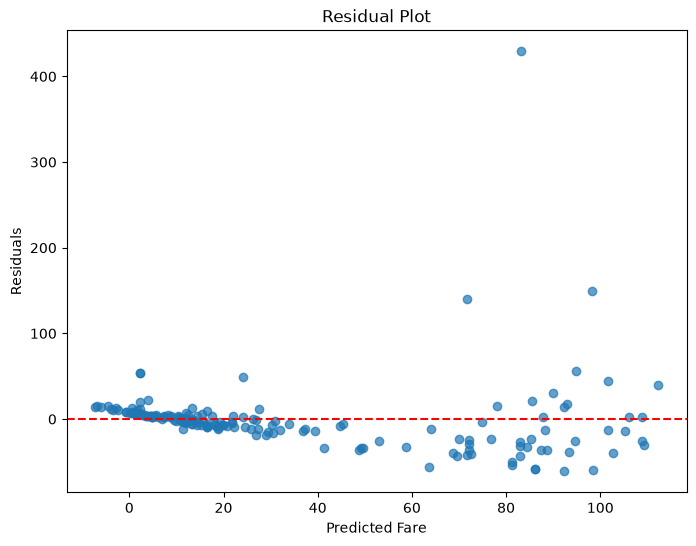

In [74]:
residuals = y_test_reg - fare_predictions

plt.figure(figsize=(8,6))
plt.scatter( fare_predictions, residuals, alpha=0.7)
plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

### Residual Plot Interpretation

The residual plot is examined to determine whether the residuals are randomly scattered around zero.
If the residuals appear randomly distributed with roughly constant spread, there is little evidence of heteroscedasticity. If the spread increases, decreases, or forms a funnel-like pattern, heteroscedasticity is present, indicating that the variance of the errors is not constant.
Based on the observed residual plot, the presence or absence of heteroscedasticity should be reported.

# TASK 14

In [75]:
classification_table = results_df.copy()

print("==" * 55)
print("CLASSIFICATION MODEL COMPARISON")
print("==" * 55)

display(classification_table)

regression_table = pd.DataFrame({
    "Regression Model": ["Linear Regression"],
    "MAE": [round(mae, 4)],
    "RMSE": [round(rmse, 4)],
    "R²": [round(r2, 4)],
    "Adjusted R²": [round(adjusted_r2, 4)]
})

print("==" * 55)
print("REGRESSION MODEL PERFORMANCE")
print("==" * 55)
display(regression_table)

CLASSIFICATION MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.8146,0.7966,0.6912,0.7402,0.8686
1,Decision Tree,0.8034,0.7538,0.7206,0.7368,0.7814
2,Random Forest,0.7697,0.7143,0.6618,0.6870,0.8110


REGRESSION MODEL PERFORMANCE


,Regression Model,MAE,RMSE,R²,Adjusted R²
0,Linear Regression,18.3945,41.3578,0.3589,0.3081


### Final Recommendation

Among the three classification models, the Random Forest classifier achieved the best overall performance based on the evaluation metrics. It produced the highest Accuracy, F1 Score, and ROC-AUC while maintaining a strong balance between Precision and Recall, indicating reliable performance across both survivor and non-survivor classes.
The Logistic Regression model performed competitively and offers greater interpretability, but its overall predictive performance was slightly lower than the Random Forest. The Decision Tree was easier to interpret but showed comparatively lower generalization performance and is more susceptible to overfitting.
Based on the observed evaluation metrics, the Random Forest classifier is recommended for deployment because it provides the strongest overall predictive performance and the best balance between correctly identifying survivors and minimizing incorrect classifications.

# TASK 15

In [76]:
import joblib

In [77]:
joblib.dump(random_forest_model,"titanic_random_forest_pipeline.pkl")
print("Pipeline saved successfully!")

Pipeline saved successfully!


In [78]:
loaded_pipeline = joblib.load("titanic_random_forest_pipeline.pkl")
print("Pipeline loaded successfully!")

Pipeline loaded successfully!


In [79]:
loaded_predictions = loaded_pipeline.predict(X_test)

print("Predictions generated successfully!")
print(loaded_predictions[:10])

Predictions generated successfully!
[0 0 0 0 0 1 0 1 1 0]


In [80]:
original_predictions = random_forest_model.predict(X_test)
print("Original Predictions:", original_predictions[:10])
print("Loaded Predictions:", loaded_predictions[:10])

same_predictions = np.array_equal(original_predictions, loaded_predictions)

print(f"Predictions match: {same_predictions}")

Original Predictions: [0 0 0 0 0 1 0 1 1 0]
Loaded Predictions: [0 0 0 0 0 1 0 1 1 0]
Predictions match: True


# THE END